In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# Загрузка датасета
titanic = pd.read_csv('train.csv')

Визуализация распределений значений признаков Survived, Pclass, Age, Sex. Parch

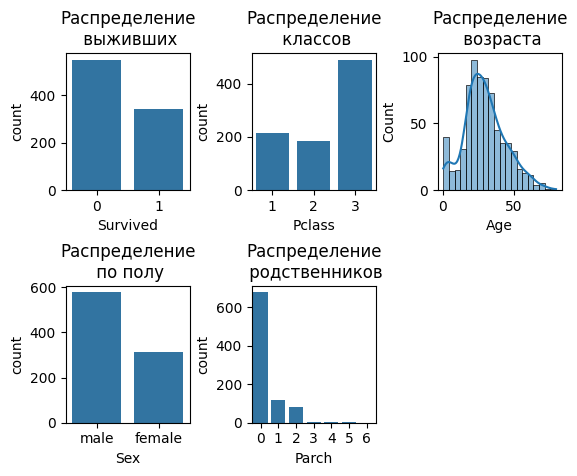

In [23]:
# Создание фигуры с несколькими subplot
plt.figure()

# 1. Распределение Survived
plt.subplot(2, 3, 1)
sns.countplot(x='Survived', data=titanic)
plt.title('Распределение\n выживших')

# 2. Распределение Pclass
plt.subplot(2, 3, 2)
sns.countplot(x='Pclass', data=titanic)
plt.title('Распределение\n классов')

# 3. Распределение Age
plt.subplot(2, 3, 3)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Распределение\n возраста')

# 4. Распределение Sex
plt.subplot(2, 3, 4)
sns.countplot(x='Sex', data=titanic)
plt.title('Распределение\n по полу')

# 5. Распределение Parch
plt.subplot(2, 3, 5)
sns.countplot(x='Parch', data=titanic)
plt.title('Распределение\n родственников')

plt.subplots_adjust(wspace=0.5, hspace=0.7)
plt.show()


График типа boxplot для столбца Age

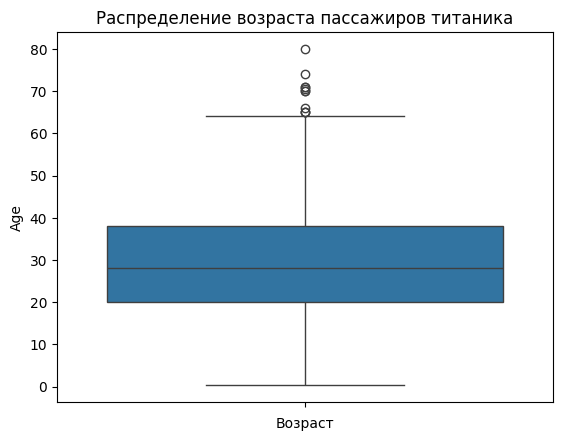

In [ ]:
# Создание графика boxplot для столбца Age
plt.figure()
titanic = titanic.dropna(subset=['Age'])
sns.boxplot(titanic['Age'])
plt.title('Распределение возраста пассажиров титаника')
plt.xlabel('Возраст')
plt.show()

Интепретация полученного графика

Данные о возрасте на Титанике показывают, что на корабле было значительное количество молодых людей: примерно 75% процентов пассажиров младше 40 лет. Средний возраст пассажиров примерно 28 лет. Самому маленькому пассажиру был примерно год, а самому пожилому было примерно около 80.

График типа pie chart для переменных Survived, Pclass (доли в процентах)

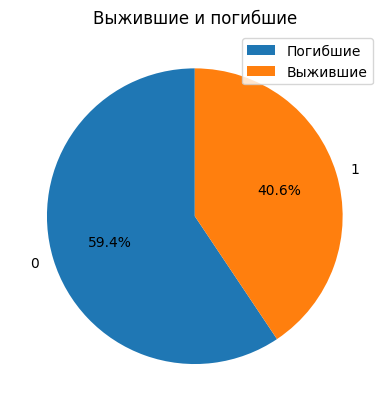

In [ ]:
# Создание графика для переменной Survived
survived_counts = titanic['Survived'].value_counts()
plt.figure()
plt.pie(survived_counts, labels=survived_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Выжившие и погибшие')
plt.legend(['Погибшие', 'Выжившие'], loc='upper right')
plt.show()

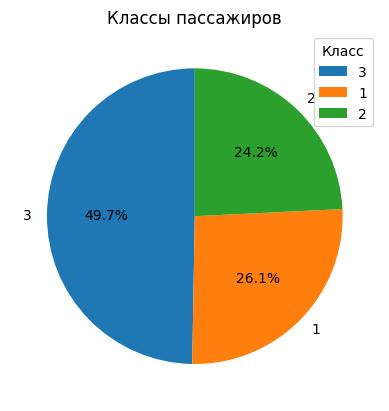

In [ ]:
# Создание графика для переменной Pclass
pclass_counts = titanic['Pclass'].value_counts()
plt.figure()
plt.pie(pclass_counts,labels=pclass_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Классы пассажиров')
plt.legend(pclass_counts.index, loc='upper right', title='Класс')
plt.show()

График типа pairplot для всех числовых переменных датасета

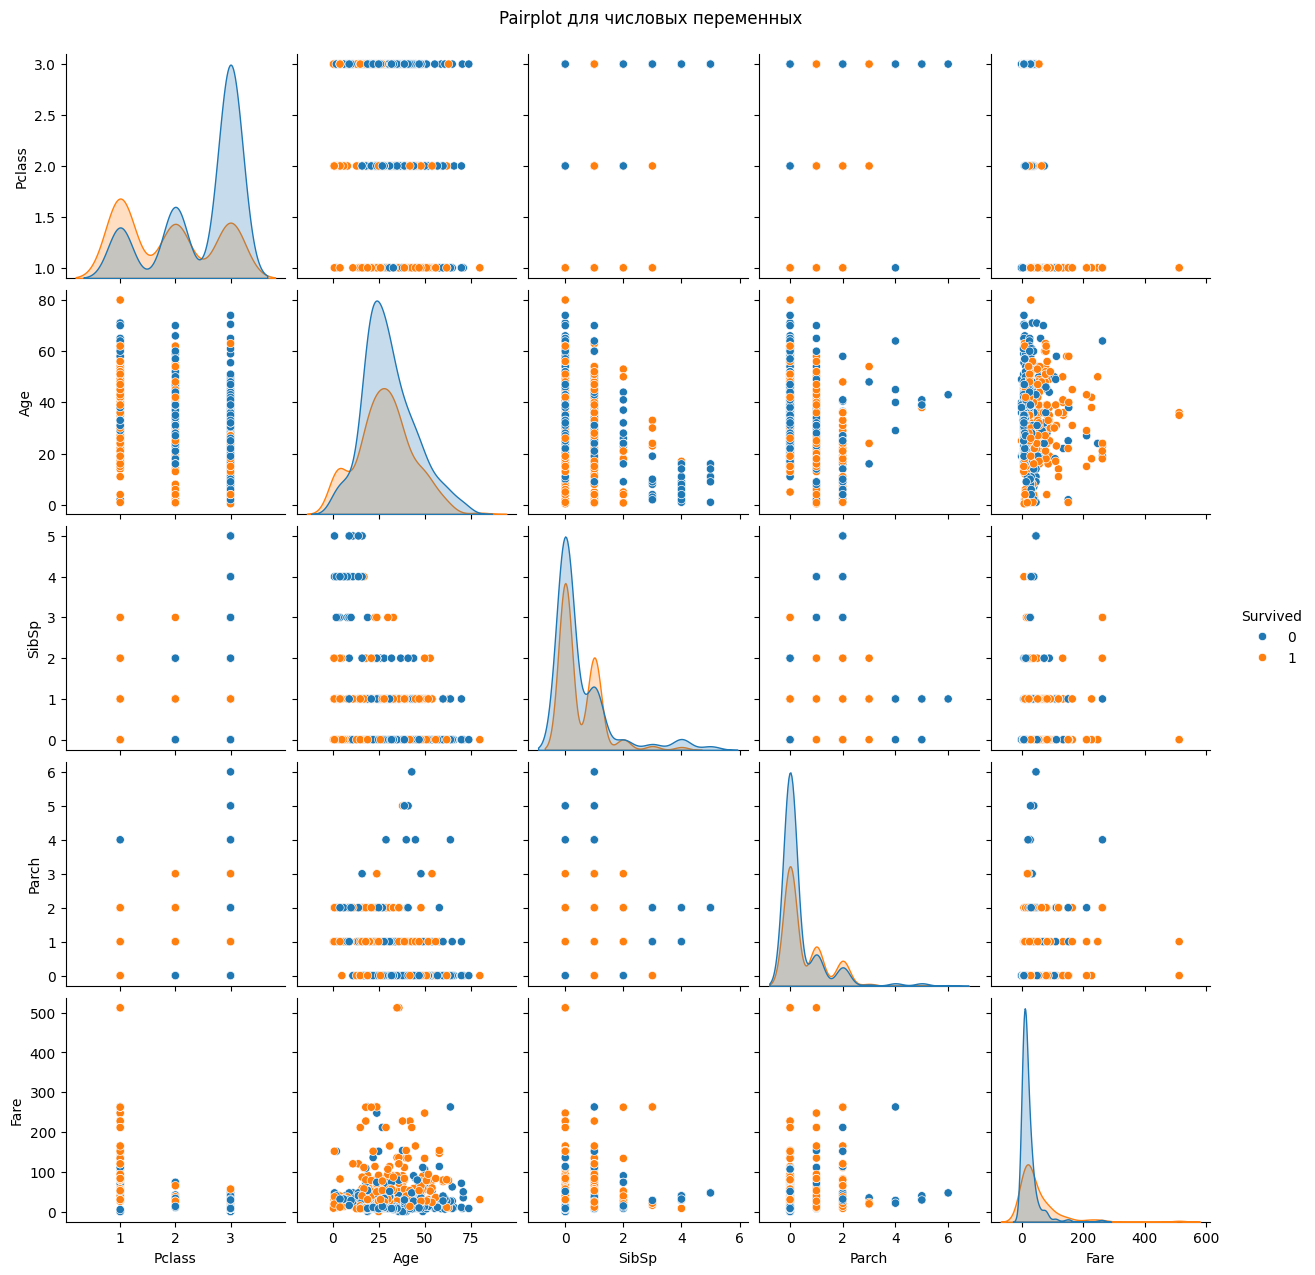

In [25]:
# Получение всех числовых переменных датасета
numerical_cols = titanic.select_dtypes(include=['int64', 'float64']).columns
# Создание графика для всех числовых переменные датасета
sns.pairplot(titanic[numerical_cols].dropna().drop('PassengerId', axis=1), hue='Survived') #dropna to handle missing values in Age
plt.suptitle('Pairplot для числовых переменных', y=1.02)
plt.show()

sunburst plot (визуализация иерархических данных) с помощью plotly. На первом уровне иерархии - количество пассажиров в каждом из классов, а на втором количество женщин/мужчин в этом классе

In [ ]:

fig = px.sunburst(
    titanic,
    path=['Pclass', 'Sex'],
    title='Распределение пассажиров по классам и полу',
)
fig.show()